# COSMOS2020 FSPS + SBI Photo-z/Mass Timing Demo

This notebook is a compact, reproducible timing demo for amortized SED inference with `sedinfer`.

The scientific object is simple: infer `log10_mass` and `z` for a large COSMOS2020 FARMER target sample using a neural posterior trained on FSPS simulations. The nuisance SED parameters are sampled from a broad prior and marginalized by simulation.

The expensive steps are protected by explicit flags, so the catalog-selection and sanity-check cells can be run safely before launching FSPS or MAF training.


## Data Flow

1. Read COSMOS2020 FARMER photometry from a local FITS file.
2. Select clean galaxies with `0 < lp_zbest < 5`, finite LePhare mass, valid `ugrizYJH` fluxes/errors, and an `r` or `i` S/N anchor.
3. Convert catalog fluxes from microJy to maggies. `sedinfer` FSPS photometry also returns maggies.
4. Convert observed and simulated fluxes to bounded asinh-magnitude features for the MAF context vector.
5. Draw FSPS parameters from the same simple prior family used in the UVEX tests.
6. Use FSPS with nebular emission and IGM absorption enabled to simulate noisy `ugrizYJH` photometry.
7. Train a conditional MAF for `q(log10_mass, z | ugrizYJH)`.
8. Time posterior sampling for 100,000 COSMOS2020 targets in large batches.

The COSMOS2020 LePhare values are used only as diagnostics. They are not treated as truth labels.


In [1]:
from __future__ import annotations

import multiprocessing as mp
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
from astropy.io import fits

import torch

from sedinfer.data import SEDDataset
from sedinfer.filters import FilterSet
from sedinfer.likelihood import GaussianPhotometricLikelihood
from sedinfer.parameters import ParameterSpace
from sedinfer.priors import UniformPrior
from sedinfer.backends.fsps import FSPSBackend
from sedinfer.units import MassNormalization

from inftools.sbi import MAFPosteriorEstimator

torch.set_default_dtype(torch.float32)
plt.rcParams.update({"font.size": 12})

In [2]:
# Local paths, run gates, and reproducibility knobs.

# Set this in the shell for a portable public notebook, for example:
# export COSMOS2020_FARMER_FITS=/path/to/cosmos2020_farmer.fits
CATALOG_PATH = Path(os.environ.get("COSMOS2020_FARMER_FITS", "cosmos2020_farmer.fits")).expanduser()

# Set SPS_HOME before constructing FSPSBackend if it is not already in the environment.
# os.environ["SPS_HOME"] = "/path/to/fsps/data"

OUTPUT_DIR = Path("outputs/cosmos2020_sbi_fsps_gpu_timing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def env_flag(name: str, default: bool = False) -> bool:
    """Read a boolean shell flag such as SEDINFER_RUN_TRAINING=1."""

    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {"1", "true", "yes", "on"}


RUN_FSPS_SIMULATION = env_flag("SEDINFER_RUN_FSPS_SIMULATION", False)
RUN_TRAINING = env_flag("SEDINFER_RUN_TRAINING", False)
RUN_POSTERIOR_SAMPLING = env_flag("SEDINFER_RUN_POSTERIOR_SAMPLING", False)

RNG_SEED = 11
rng = np.random.default_rng(RNG_SEED)

# Public-demo scale. Reduce these when testing the notebook interactively.
N_TARGET = 100_000
N_TRAIN_SIMS = 100_000
N_POST_SAMPLES = 128

# Inference batch size is the batch of COSMOS objects passed to the MAF sampler.
# It is separate from the MAF training batch size.
INFERENCE_BATCH_SIZE = int(os.environ.get("SEDINFER_INFERENCE_BATCH_SIZE", str(2**16)))

# FSPS is process-parallel here because each SED call is independent.
N_FSPS_PROCS = int(os.environ.get("SEDINFER_FSPS_PROCS", "14"))
FSPS_CHUNKSIZE = int(os.environ.get("SEDINFER_FSPS_CHUNKSIZE", "32"))

TRAINING_CACHE = OUTPUT_DIR / f"training_fsps_ugrizYJH_igm_{N_TRAIN_SIMS}.npz"
ESTIMATOR_PATH = OUTPUT_DIR / "maf_posterior_state.pt"
POSTERIOR_SAMPLE_PATH = OUTPUT_DIR / "cosmos2020_posterior_samples.npz"
POSTERIOR_MEDIAN_PATH = OUTPUT_DIR / "cosmos2020_posterior_medians.npz"
LEPHARE_COMPARISON_PNG = OUTPUT_DIR / "cosmos2020_lephare_vs_sedinfer_posterior_median.png"
LEPHARE_COMPARISON_PDF = OUTPUT_DIR / "cosmos2020_lephare_vs_sedinfer_posterior_median.pdf"

print("catalog:", CATALOG_PATH)
print("output directory:", OUTPUT_DIR)
print("run flags:", RUN_FSPS_SIMULATION, RUN_TRAINING, RUN_POSTERIOR_SAMPLING)


In [3]:
# -------------------------
# Bands and filters
# -------------------------

BAND_NAMES = ["u", "g", "r", "i", "z", "Y", "J", "H"]

# COSMOS2020 FARMER column roots.
CATALOG_BANDS = [
    "cfht_u",
    "hsc_g",
    "hsc_r",
    "hsc_i",
    "hsc_z",
    "hsc_y",
    "uvista_j",
    "uvista_h",
]

# sedpy/FSPS filter names. These are close matches to the COSMOS2020 columns above.
FILTER_NAMES = [
    "cfht_megacam_us_9301",
    "hsc_g",
    "hsc_r",
    "hsc_i",
    "hsc_z",
    "hsc_y",
    "vista_vircam_J",
    "vista_vircam_H",
]

# COSMOS2020 FARMER fluxes use the AB microJy convention: mag = 23.9 - 2.5 log10(flux_uJy).
MICROJY_TO_MAGGIES = 10.0 ** (-0.4 * 23.9)

In [4]:
def load_cosmos2020_target_subset(path: Path, n_target: int, seed: int = 11) -> dict[str, np.ndarray]:
    """Load one reproducible COSMOS2020 target subset.

    Returned fluxes are in maggies because that is the sedinfer/FSPS likelihood
    convention. The `z_ref` and `log10_mass_ref` arrays are LePhare catalog
    estimates used only for sanity plots.
    """

    path = Path(path).expanduser()
    if not path.exists():
        raise FileNotFoundError(
            f"Missing COSMOS2020 catalog: {path}. Set COSMOS2020_FARMER_FITS to the FITS file."
        )

    with fits.open(path, memmap=True) as hdul:
        catalog = hdul[1].data
        n_rows = len(catalog)

        clean_galaxy = np.ones(n_rows, dtype=bool)
        clean_galaxy &= np.isfinite(catalog["lp_zbest"])
        clean_galaxy &= (catalog["lp_zbest"] > 0.0) & (catalog["lp_zbest"] < 5.0)
        clean_galaxy &= np.isfinite(catalog["lp_mass_med"])
        clean_galaxy &= (catalog["lp_mass_med"] > 5.0) & (catalog["lp_mass_med"] < 14.0)
        clean_galaxy &= catalog["lp_type"] == 0
        clean_galaxy &= catalog["flag_combined"] == 0

        valid_photometry = np.ones(n_rows, dtype=bool)
        for band in CATALOG_BANDS:
            valid_photometry &= catalog[f"{band}_valid"] > 0
            valid_photometry &= np.isfinite(catalog[f"{band}_flux"])
            valid_photometry &= np.isfinite(catalog[f"{band}_fluxerr"])
            valid_photometry &= catalog[f"{band}_fluxerr"] > 0.0

        snr_r = np.asarray(catalog["hsc_r_flux"] / catalog["hsc_r_fluxerr"], dtype=float)
        snr_i = np.asarray(catalog["hsc_i_flux"] / catalog["hsc_i_fluxerr"], dtype=float)
        detected_in_optical = (snr_r > 5.0) | (snr_i > 5.0)

        selected = clean_galaxy & valid_photometry & detected_in_optical
        eligible_rows = np.flatnonzero(selected)
        if eligible_rows.size == 0:
            raise RuntimeError("COSMOS2020 target selection produced no rows.")

        local_rng = np.random.default_rng(seed)
        picked_rows = local_rng.choice(eligible_rows, size=min(int(n_target), eligible_rows.size), replace=False)
        picked_rows.sort()

        flux_uJy = np.vstack(
            [np.asarray(catalog[f"{band}_flux"][picked_rows], dtype=float) for band in CATALOG_BANDS]
        ).T
        sigma_uJy = np.vstack(
            [np.asarray(catalog[f"{band}_fluxerr"][picked_rows], dtype=float) for band in CATALOG_BANDS]
        ).T

        return {
            "row_index": picked_rows.astype(np.int64),
            "flux_maggies": (flux_uJy * MICROJY_TO_MAGGIES).astype(np.float32),
            "sigma_maggies": (sigma_uJy * MICROJY_TO_MAGGIES).astype(np.float32),
            "flux_uJy": flux_uJy.astype(np.float32),
            "sigma_uJy": sigma_uJy.astype(np.float32),
            "z_ref": np.asarray(catalog["lp_zbest"][picked_rows], dtype=np.float32),
            "log10_mass_ref": np.asarray(catalog["lp_mass_med"][picked_rows], dtype=np.float32),
            "n_catalog_rows": np.array(n_rows),
            "n_eligible": np.array(eligible_rows.size),
        }


target = load_cosmos2020_target_subset(CATALOG_PATH, n_target=N_TARGET, seed=RNG_SEED)
x_obs_flux = target["flux_maggies"]
sigma_obs = target["sigma_maggies"]

print(f"Catalog rows: {int(target['n_catalog_rows']):,}")
print(f"Eligible rows: {int(target['n_eligible']):,}")
print(f"Selected targets: {len(x_obs_flux):,}")
print(f"Flux matrix shape: {x_obs_flux.shape}  (objects, bands)")
print(
    f"z_ref median/range: {np.median(target['z_ref']):.3f} / "
    f"{target['z_ref'].min():.3f}..{target['z_ref'].max():.3f}"
)
print(
    f"log10_mass_ref median/range: {np.median(target['log10_mass_ref']):.3f} / "
    f"{target['log10_mass_ref'].min():.3f}..{target['log10_mass_ref'].max():.3f}"
)


Catalog rows: 964,506
Eligible rows: 636,734
Selected targets: 100,000
x_obs shape: (100000, 8)
z_ref median/range: 1.151 / 0.020..5.000
log10_mass_ref median/range: 8.558 / 5.002..12.000


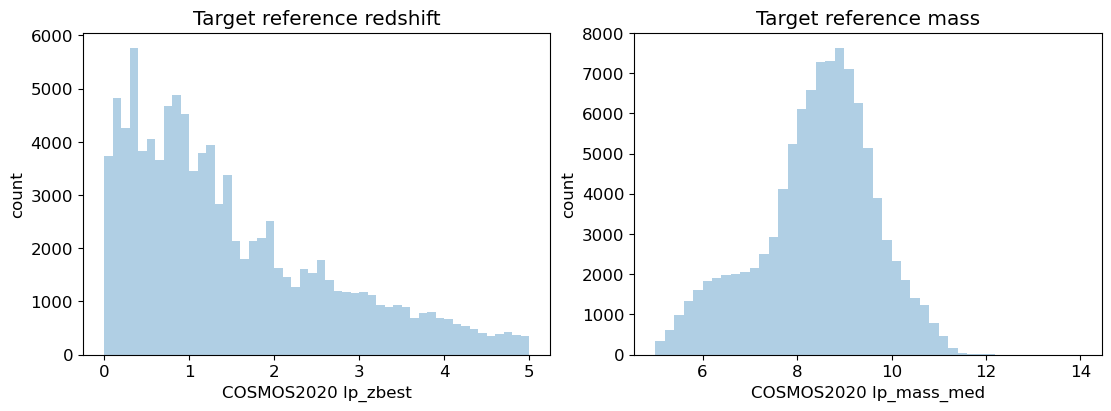

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].hist(target["z_ref"], bins=np.linspace(0, 5, 51), histtype="stepfilled", alpha=0.35)
ax[0].set_xlabel("COSMOS2020 lp_zbest")
ax[0].set_ylabel("count")
ax[0].set_title("Target reference redshift")

ax[1].hist(target["log10_mass_ref"], bins=np.linspace(5, 14, 46), histtype="stepfilled", alpha=0.35)
ax[1].set_xlabel("COSMOS2020 lp_mass_med")
ax[1].set_ylabel("count")
ax[1].set_title("Target reference mass")
plt.show()

## Prior and FSPS Simulator

The simulator prior is intentionally simple and broad. The posterior target is only `[log10_mass, z]`; the other SED parameters are nuisance variables integrated out by simulation.

The mass convention is explicit: FSPS returns photometry per solar mass, and `GaussianPhotometricLikelihood.simulate` multiplies by `10**log10_mass` because the backend declares `MassNormalization.PER_SOLAR_MASS`.


In [6]:
parameter_space = ParameterSpace(
    names=["z", "log10_mass", "logzsol", "tau", "tage", "dust2"],
    priors={
        "z": UniformPrior(0.0, 5.0),
        "log10_mass": UniformPrior(5.0, 14.0),
        "logzsol": UniformPrior(-1.0, 0.2),
        "tau": UniformPrior(0.2, 5.0),
        "tage": UniformPrior(0.5, 13.0),
        "dust2": UniformPrior(0.0, 2.0),
    },
)
theta_names = list(parameter_space.names)
target_columns = [theta_names.index("log10_mass"), theta_names.index("z")]
target_names = ["log10_mass", "z"]
print("Full simulator parameter order:", theta_names)
print("Neural posterior target order:", target_names)

Full simulator parameter order: ['z', 'log10_mass', 'logzsol', 'tau', 'tage', 'dust2']
Neural posterior target order: ['log10_mass', 'z']


In [7]:
SFH_START_GYR = 0.1
SFH_N_BINS = 50

FSPS_SP_KWARGS = {
    "zcontinuous": 1,
    "sfh": 3,
    "add_dust_emission": True,
    "add_neb_emission": True,
    "add_igm_absorption": True,
    "igm_factor": 1.0,
    "compute_vega_mags": False,
}


def tau_tage_to_tabular_sfh(tau_gyr: float, tage_gyr: float) -> tuple[np.ndarray, np.ndarray]:
    """Convert the notebook tau/tage prior to the tabular SFH FSPS expects."""

    tau_gyr = float(tau_gyr)
    tage_gyr = float(tage_gyr)
    if tau_gyr <= 0.0 or tage_gyr <= 0.0:
        raise ValueError("tau and tage must be positive.")

    time_gyr = np.linspace(SFH_START_GYR, SFH_START_GYR + tage_gyr, SFH_N_BINS)
    sfr_msun_per_yr = np.exp(-(time_gyr - SFH_START_GYR) / tau_gyr)
    return time_gyr, sfr_msun_per_yr


class TauModelFSPSBackend(FSPSBackend):
    """Small notebook adapter from tau/tage parameters to FSPS tabular SFHs."""

    def predict_photometry(self, params, filters):
        fsps_params = dict(params)
        time_gyr, sfr_msun_per_yr = tau_tage_to_tabular_sfh(
            tau_gyr=fsps_params.pop("tau"),
            tage_gyr=fsps_params.pop("tage"),
        )
        fsps_params["tabular_time_gyr"] = time_gyr
        fsps_params["tabular_sfr_msun_per_yr"] = sfr_msun_per_yr
        fsps_params.setdefault("dust1", 0.0)
        return super().predict_photometry(fsps_params, filters)


def load_filter_set() -> FilterSet:
    from sedpy.observate import load_filters

    return FilterSet(load_filters(FILTER_NAMES), names=BAND_NAMES)


def build_likelihood() -> GaussianPhotometricLikelihood:
    filters = load_filter_set()
    backend = TauModelFSPSBackend(
        sp_kwargs=FSPS_SP_KWARGS,
        mass_normalization=MassNormalization.PER_SOLAR_MASS,
        default_z_key="z",
    )
    dataset = SEDDataset(
        band_names=BAND_NAMES,
        flux=np.zeros(len(BAND_NAMES), dtype=float),
        sigma=np.ones(len(BAND_NAMES), dtype=float),
        metadata={"filters": filters},
    )
    return GaussianPhotometricLikelihood(backend, dataset, parameter_space)


print("FSPS options used for the simulator:")
for key, value in FSPS_SP_KWARGS.items():
    print(f"  {key}: {value}")


IGM absorption will be enabled through FSPS sp_kwargs: add_igm_absorption=True, igm_factor=1.0


In [8]:
def sample_valid_theta(n: int, batch: int = 8192, seed: int = RNG_SEED) -> np.ndarray:
    """Sample prior rows and reject SFHs older than the Universe at that redshift."""

    local_rng = np.random.default_rng(seed)
    accepted = []
    while sum(len(rows) for rows in accepted) < int(n):
        candidate = parameter_space.sample_prior(batch, rng=local_rng).astype(np.float32)
        z = candidate[:, theta_names.index("z")]
        tage_gyr = candidate[:, theta_names.index("tage")]
        age_universe_gyr = np.array([cosmo.age(float(zz)).value for zz in z], dtype=np.float32)
        physically_allowed = SFH_START_GYR + tage_gyr <= age_universe_gyr - 1e-4
        if np.any(physically_allowed):
            accepted.append(candidate[physically_allowed])
    return np.concatenate(accepted, axis=0)[: int(n)].astype(np.float32)


# Noise model used for simulated training photometry. It is deliberately simple:
# median COSMOS2020 error per band plus a 5% fractional flux term.
sigma_abs_maggies = np.median(sigma_obs, axis=0).astype(np.float32)
frac_noise = 0.05


def cosmos_noise_sigma(flux_maggies):
    """Return Gaussian sigma in maggies for the simulator flux array."""

    flux_maggies = np.asarray(flux_maggies, dtype=np.float32)
    return np.sqrt(sigma_abs_maggies**2 + (frac_noise * np.abs(flux_maggies))**2).astype(np.float32)


def flux_to_asinh_mag(flux_maggies, softening_maggies=None, clip=(-5.0, 45.0)):
    """Convert maggies to finite asinh-magnitude features.

    Raw fluxes span many orders of magnitude. These features are still
    monotonic in flux for high-S/N detections, but negative noisy fluxes remain
    finite, which is useful for neural density estimation.
    """

    flux_maggies = np.asarray(flux_maggies, dtype=np.float32)
    if softening_maggies is None:
        softening_maggies = sigma_abs_maggies
    softening_maggies = np.maximum(np.asarray(softening_maggies, dtype=np.float32), 1e-30)
    mag = -(2.5 / np.log(10.0)) * (
        np.arcsinh(flux_maggies / (2.0 * softening_maggies)) + np.log(softening_maggies)
    )
    if clip is not None:
        mag = np.clip(mag, clip[0], clip[1])
    return mag.astype(np.float32)


x_obs = flux_to_asinh_mag(x_obs_flux)

print("Median catalog sigma per band, microJy:")
for name, value in zip(BAND_NAMES, sigma_abs_maggies / MICROJY_TO_MAGGIES):
    print(f"  {name:>2s}: {value:.5g}")
print("SBI context feature shape:", x_obs.shape)
print("SBI context feature finite:", np.isfinite(x_obs).all())
print("SBI context feature median/range:", float(np.median(x_obs)), float(np.min(x_obs)), float(np.max(x_obs)))


Median catalog sigma per band, microJy:
   u: 0.0043552
   g: 0.0033081
   r: 0.0042916
   i: 0.0043059
   z: 0.0067754
   Y: 0.015461
   J: 0.02105
   H: 0.026979
SBI context feature shape: (100000, 8)
SBI context feature finite: True
SBI context feature median/range: 26.028087615966797 13.22382640838623 39.85862350463867


## Heavy Step 1: FSPS Simulations

This cell draws full SED parameters from the prior, runs FSPS through the sedinfer likelihood simulator, adds the empirical flux noise, converts to asinh-magnitude features, and saves the training set.

Audit points before enabling it:

- `SPS_HOME` is correct;
- the selected target sample has the expected size and redshift range;
- the median catalog errors look sane;
- `add_igm_absorption=True` and `add_neb_emission=True` are printed above.


In [9]:
def zero_noise_sigma(flux):
    """Noise function used when we want the deterministic FSPS model flux."""

    return np.zeros_like(flux)


_FSPS_WORKER_LIKELIHOOD = None


def _init_fsps_worker(sps_home: str | None):
    global _FSPS_WORKER_LIKELIHOOD
    if sps_home:
        os.environ["SPS_HOME"] = str(sps_home)

    # Keep numerical libraries from over-subscribing every worker process.
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")
    os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

    _FSPS_WORKER_LIKELIHOOD = build_likelihood()


def _simulate_noiseless_one(theta_row):
    if _FSPS_WORKER_LIKELIHOOD is None:
        raise RuntimeError("FSPS worker likelihood is not initialized.")
    return _FSPS_WORKER_LIKELIHOOD.simulate(
        np.asarray(theta_row, dtype=float),
        noise_fn=zero_noise_sigma,
    ).astype(np.float32)


def simulate_training_photometry(n_train: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Create the FSPS training set saved for the MAF posterior."""

    theta_full = sample_valid_theta(n_train)
    print(f"Running FSPS simulations: n={n_train:,}, n_procs={N_FSPS_PROCS}, chunksize={FSPS_CHUNKSIZE}")
    t0 = time.perf_counter()

    if N_FSPS_PROCS > 1:
        ctx = mp.get_context("fork")
        rows = []
        with ctx.Pool(
            processes=N_FSPS_PROCS,
            initializer=_init_fsps_worker,
            initargs=(os.environ.get("SPS_HOME"),),
        ) as pool:
            for i, flux in enumerate(pool.imap(_simulate_noiseless_one, theta_full, chunksize=FSPS_CHUNKSIZE), start=1):
                rows.append(flux)
                if i % 5000 == 0 or i == n_train:
                    dt = time.perf_counter() - t0
                    print(f"  FSPS {i:,}/{n_train:,} in {dt:.1f}s -> {i / max(dt, 1e-9):.1f}/s")
        x_noiseless = np.asarray(rows, dtype=np.float32)
    else:
        _init_fsps_worker(os.environ.get("SPS_HOME"))
        x_noiseless = np.empty((n_train, len(BAND_NAMES)), dtype=np.float32)
        for i, theta in enumerate(theta_full):
            x_noiseless[i] = _simulate_noiseless_one(theta)
            if (i + 1) % 5000 == 0 or (i + 1) == n_train:
                dt = time.perf_counter() - t0
                print(f"  FSPS {i + 1:,}/{n_train:,} in {dt:.1f}s -> {(i + 1) / max(dt, 1e-9):.1f}/s")

    sigma_train = cosmos_noise_sigma(x_noiseless)
    x_train_flux = (x_noiseless + rng.normal(0.0, sigma_train)).astype(np.float32)
    x_train_features = flux_to_asinh_mag(x_train_flux)
    theta_target = theta_full[:, target_columns].astype(np.float32)
    return theta_full, theta_target, x_noiseless, x_train_flux, x_train_features


if RUN_FSPS_SIMULATION:
    theta_full, theta_train, x_noiseless, x_train_flux, x_train = simulate_training_photometry(N_TRAIN_SIMS)
    np.savez_compressed(
        TRAINING_CACHE,
        theta_full=theta_full,
        theta_train=theta_train,
        x_noiseless=x_noiseless,
        x_train_flux=x_train_flux,
        x_train_features=x_train,
        band_names=np.array(BAND_NAMES, dtype=object),
        filter_names=np.array(FILTER_NAMES, dtype=object),
        target_names=np.array(target_names, dtype=object),
        sigma_abs_maggies=sigma_abs_maggies,
        frac_noise=np.array(frac_noise),
    )
    print("Saved", TRAINING_CACHE)
else:
    print("RUN_FSPS_SIMULATION=False; skipping FSPS simulation.")


RUN_FSPS_SIMULATION=False; skipping FSPS simulation.


## Heavy Step 2: Train Conditional MAF

The flow estimates `q(log10_mass, z | ugrizYJH)`. The input features are the asinh magnitudes built above; the labels are the simulated `[log10_mass, z]` columns. Training uses `float32` so that MPS/CUDA devices do not silently fall back or fail on unsupported `float64` operations.


In [10]:
def choose_torch_device(requested: str = "auto") -> str:
    requested = requested.lower()
    if requested == "mps":
        if not torch.backends.mps.is_available():
            raise RuntimeError("MPS was requested but torch.backends.mps.is_available() is False.")
        return "mps"
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested but torch.cuda.is_available() is False.")
        return "cuda"
    if requested == "cpu":
        return "cpu"
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


POSTERIOR_DEVICE = choose_torch_device(os.environ.get("SEDINFER_POSTERIOR_DEVICE", "auto"))
print("torch:", torch.__version__)
print("mps built:", torch.backends.mps.is_built())
print("mps available:", torch.backends.mps.is_available())
print("posterior device:", POSTERIOR_DEVICE)

MAF_CONFIG = dict(
    theta_dim=2,
    x_dim=len(BAND_NAMES),
    hidden_features=128,
    num_transforms=6,
    num_blocks=2,
    learning_rate=3e-4,
    device=POSTERIOR_DEVICE,
    standardize=True,
)
TRAINING_CONFIG = dict(epochs=200, batch_size=1024, seed=RNG_SEED, verbose=True)
print(MAF_CONFIG)

torch: 2.7.1
mps built: True
mps available: True
posterior device: mps
{'theta_dim': 2, 'x_dim': 8, 'hidden_features': 128, 'num_transforms': 6, 'num_blocks': 2, 'learning_rate': 0.0003, 'device': 'mps', 'standardize': True}


In [11]:
if RUN_TRAINING:
    train = np.load(TRAINING_CACHE, allow_pickle=True)
    theta_train = train["theta_train"].astype(np.float32)
    if "x_train_features" in train.files:
        x_train = train["x_train_features"].astype(np.float32)
    else:
        x_train = flux_to_asinh_mag(train["x_train"].astype(np.float32))
    if not np.all(np.isfinite(x_train)):
        raise FloatingPointError("SBI training features contain NaN or inf values.")
    print("Training feature median/range:", float(np.median(x_train)), float(np.min(x_train)), float(np.max(x_train)))
    estimator = MAFPosteriorEstimator(**MAF_CONFIG)
    history = estimator.fit(theta_train, x_train, **TRAINING_CONFIG)
    torch.save(
        {
            "flow_state_dict": estimator.flow.state_dict(),
            "theta_standardizer": estimator.theta_standardizer,
            "x_standardizer": estimator.x_standardizer,
            "history": history,
            "maf_config": MAF_CONFIG,
            "training_config": TRAINING_CONFIG,
        },
        ESTIMATOR_PATH,
    )
    print("Saved", ESTIMATOR_PATH)
else:
    print("RUN_TRAINING=False; skipping MAF training.")

RUN_TRAINING=False; skipping MAF training.


## Posterior Sampling Timing

This is the timing number the demo cares about. It includes standardization, nflows sampling, inverse transformation, and transfer back to NumPy arrays, because that is the end-to-end path a science script would use.

`INFERENCE_BATCH_SIZE` controls how many galaxies are sampled at once. Large values are important for GPU/MPS throughput.


In [12]:
def sync_torch_device(device: str) -> None:
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def sample_posterior_in_batches(estimator, x_context, num_samples=128, inference_batch_size=8192):
    """Draw posterior samples for many galaxies without looping one by one."""

    x_context = np.asarray(x_context, dtype=np.float32)
    batches = []
    for lo in range(0, x_context.shape[0], int(inference_batch_size)):
        hi = min(lo + int(inference_batch_size), x_context.shape[0])
        batch_samples = estimator.sample(x_context[lo:hi], num_samples=num_samples)
        batches.append(np.asarray(batch_samples, dtype=np.float32))
    return np.concatenate(batches, axis=0)


def benchmark_posterior_sampling(estimator, x_context, num_samples=128, inference_batch_size=8192, n_warmup=2, n_runs=5):
    x_context = np.asarray(x_context, dtype=np.float32)
    warmup_context = x_context[: min(len(x_context), int(inference_batch_size))]
    for _ in range(n_warmup):
        _ = estimator.sample(warmup_context, num_samples=num_samples)
    sync_torch_device(str(estimator.device))

    times = []
    samples = None
    for _ in range(n_runs):
        sync_torch_device(str(estimator.device))
        t0 = time.perf_counter()
        samples = sample_posterior_in_batches(
            estimator,
            x_context,
            num_samples=num_samples,
            inference_batch_size=inference_batch_size,
        )
        sync_torch_device(str(estimator.device))
        times.append(time.perf_counter() - t0)

    times = np.asarray(times)
    n_theta_draws = x_context.shape[0] * int(num_samples)
    print(f"Device: {estimator.device}")
    print(f"Number of galaxies: {x_context.shape[0]:,}")
    print(f"Inference batch size: {inference_batch_size:,}")
    print(f"Posterior samples per galaxy: {num_samples:,}")
    print(f"Output sample shape: {samples.shape}")
    print(f"Mean sample time: {times.mean():.4f} s")
    print(f"Min sample time:  {times.min():.4f} s")
    print(f"Max sample time:  {times.max():.4f} s")
    print(f"Mean theta-draw rate: {n_theta_draws / times.mean():.1f} / s")
    return samples, times


if RUN_POSTERIOR_SAMPLING:
    estimator = MAFPosteriorEstimator(**MAF_CONFIG)
    state = torch.load(ESTIMATOR_PATH, map_location=POSTERIOR_DEVICE, weights_only=False)
    estimator.flow.load_state_dict(state["flow_state_dict"])
    estimator.theta_standardizer = state["theta_standardizer"]
    estimator.x_standardizer = state["x_standardizer"]

    posterior_samples, sampling_times = benchmark_posterior_sampling(
        estimator,
        x_obs,
        num_samples=N_POST_SAMPLES,
        inference_batch_size=INFERENCE_BATCH_SIZE,
        n_warmup=2,
        n_runs=5,
    )
    np.savez_compressed(
        POSTERIOR_SAMPLE_PATH,
        samples=posterior_samples.astype(np.float32),
        sampling_times=sampling_times.astype(np.float32),
        x_obs=x_obs.astype(np.float32),
        x_obs_flux=x_obs_flux.astype(np.float32),
        sigma_obs=sigma_obs.astype(np.float32),
        z_ref=target["z_ref"].astype(np.float32),
        log10_mass_ref=target["log10_mass_ref"].astype(np.float32),
        target_names=np.array(target_names, dtype=object),
    )
    print("Saved", POSTERIOR_SAMPLE_PATH)
else:
    print("RUN_POSTERIOR_SAMPLING=False; skipping posterior sampling benchmark.")


Device: mps
Total context batch size: 100000
Inference batch size: 65536
Num samples per context: 128
Output sample shape: (100000, 128, 2)
Mean sample time: 13.2810 s
Min sample time:  12.5128 s
Max sample time:  15.4854 s
Mean theta-draw rate: 963780.9 / s


Saved outputs/cosmos2020_sbi_fsps_gpu_timing/cosmos2020_posterior_samples.npz


## LePhare Comparison Diagnostics

These plots compare sedinfer posterior medians to the COSMOS2020 LePhare catalog values for the same selected galaxies. This is a sanity check and communication plot, not a validation against spectroscopic truth.


Comparison rows: 100,000/100,000
z posterior median vs COSMOS2020 LePhare lp_zbest:
  median dz/(1+z):  0.0133
  NMAD dz/(1+z):    0.1188
  MAE dz:           0.5663
  RMSE dz:          1.0440
log10_mass posterior median vs COSMOS2020 LePhare lp_mass_med:
  median dlogM:     0.4131
  NMAD dlogM:       0.4985
  MAE dlogM:        0.8121
  RMSE dlogM:       1.1440


Saved outputs/cosmos2020_sbi_fsps_gpu_timing/cosmos2020_posterior_medians.npz
Saved outputs/cosmos2020_sbi_fsps_gpu_timing/cosmos2020_lephare_vs_sedinfer_posterior_median.png
Saved outputs/cosmos2020_sbi_fsps_gpu_timing/cosmos2020_lephare_vs_sedinfer_posterior_median.pdf


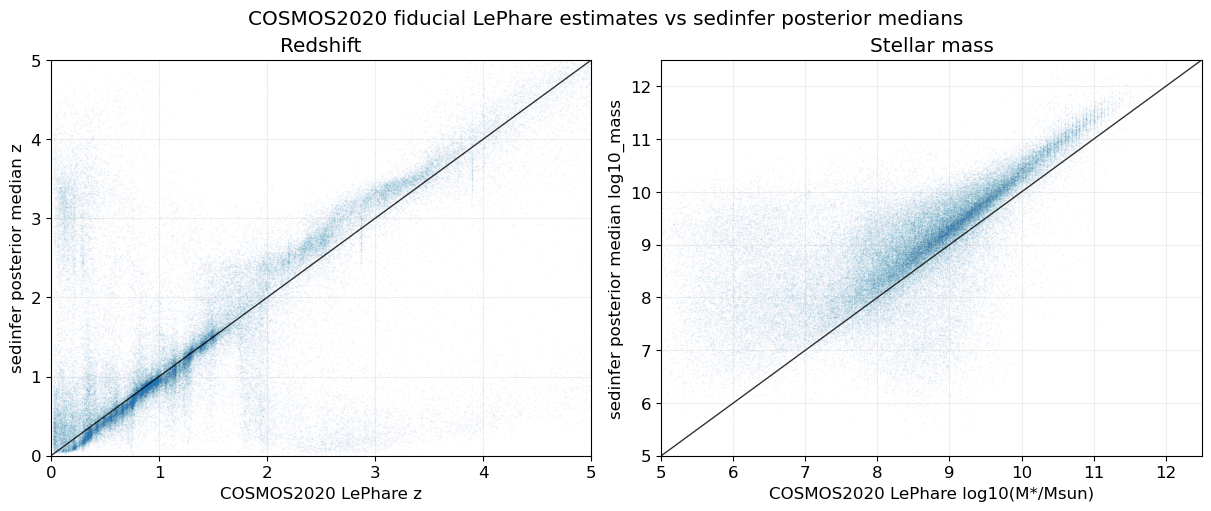

In [13]:
def load_posterior_samples_for_diagnostics():
    if "posterior_samples" in globals():
        return np.asarray(posterior_samples, dtype=np.float32)
    if POSTERIOR_SAMPLE_PATH.exists():
        with np.load(POSTERIOR_SAMPLE_PATH, allow_pickle=True) as data:
            return data["samples"].astype(np.float32)
    raise FileNotFoundError(
        f"No posterior samples available at {POSTERIOR_SAMPLE_PATH}. "
        "Run with SEDINFER_RUN_POSTERIOR_SAMPLING=1 first."
    )


def nmad(delta):
    delta = np.asarray(delta, dtype=float)
    med = np.nanmedian(delta)
    return 1.4826 * np.nanmedian(np.abs(delta - med))


samples_for_diag = load_posterior_samples_for_diagnostics()
posterior_median = np.nanmedian(samples_for_diag, axis=1).astype(np.float32)

# target_names = ["log10_mass", "z"]. Keep this explicit so plots cannot silently swap axes.
log10_mass_sedinfer = posterior_median[:, target_names.index("log10_mass")]
z_sedinfer = posterior_median[:, target_names.index("z")]
z_lephare = target["z_ref"].astype(np.float32)
log10_mass_lephare = target["log10_mass_ref"].astype(np.float32)

finite = (
    np.isfinite(z_lephare)
    & np.isfinite(z_sedinfer)
    & np.isfinite(log10_mass_lephare)
    & np.isfinite(log10_mass_sedinfer)
)
if not np.all(finite):
    print(f"Dropping {np.size(finite) - np.count_nonzero(finite)} rows with non-finite comparison values.")

z_lephare_plot = z_lephare[finite]
z_sedinfer_plot = z_sedinfer[finite]
log10_mass_lephare_plot = log10_mass_lephare[finite]
log10_mass_sedinfer_plot = log10_mass_sedinfer[finite]

np.savez_compressed(
    POSTERIOR_MEDIAN_PATH,
    posterior_median=posterior_median,
    z_sedinfer=z_sedinfer,
    log10_mass_sedinfer=log10_mass_sedinfer,
    z_lephare=z_lephare,
    log10_mass_lephare=log10_mass_lephare,
    target_names=np.array(target_names, dtype=object),
)

z_delta = z_sedinfer_plot - z_lephare_plot
z_delta_norm = z_delta / (1.0 + z_lephare_plot)
mass_delta = log10_mass_sedinfer_plot - log10_mass_lephare_plot

print(f"Comparison rows: {finite.sum():,}/{len(finite):,}")
print("z posterior median minus COSMOS2020 LePhare lp_zbest:")
print(f"  median dz/(1+z): {np.median(z_delta_norm): .4f}")
print(f"  NMAD dz/(1+z):   {nmad(z_delta_norm): .4f}")
print(f"  MAE dz:          {np.mean(np.abs(z_delta)): .4f}")
print(f"  RMSE dz:         {np.sqrt(np.mean(z_delta**2)): .4f}")
print("log10_mass posterior median minus COSMOS2020 LePhare lp_mass_med:")
print(f"  median dlogM:    {np.median(mass_delta): .4f}")
print(f"  NMAD dlogM:      {nmad(mass_delta): .4f}")
print(f"  MAE dlogM:       {np.mean(np.abs(mass_delta)): .4f}")
print(f"  RMSE dlogM:      {np.sqrt(np.mean(mass_delta**2)): .4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax = axes[0]
ax.scatter(z_lephare_plot, z_sedinfer_plot, s=1.0, alpha=0.05, linewidths=0, rasterized=True)
z_min = min(0.0, float(np.nanpercentile(z_sedinfer_plot, 0.2)))
z_max = max(5.0, float(np.nanpercentile(z_sedinfer_plot, 99.8)))
ax.plot([z_min, z_max], [z_min, z_max], color="black", lw=1.0, alpha=0.8)
ax.set_xlim(z_min, z_max)
ax.set_ylim(z_min, z_max)
ax.set_xlabel("COSMOS2020 LePhare z")
ax.set_ylabel("sedinfer posterior median z")
ax.set_title("Redshift")
ax.grid(alpha=0.2)

ax = axes[1]
ax.scatter(
    log10_mass_lephare_plot,
    log10_mass_sedinfer_plot,
    s=1.0,
    alpha=0.05,
    linewidths=0,
    rasterized=True,
)
m_min = min(5.0, float(np.nanpercentile(log10_mass_sedinfer_plot, 0.2)))
m_max = max(12.5, float(np.nanpercentile(log10_mass_sedinfer_plot, 99.8)))
ax.plot([m_min, m_max], [m_min, m_max], color="black", lw=1.0, alpha=0.8)
ax.set_xlim(m_min, m_max)
ax.set_ylim(m_min, m_max)
ax.set_xlabel("COSMOS2020 LePhare log10(M*/Msun)")
ax.set_ylabel("sedinfer posterior median log10_mass")
ax.set_title("Stellar mass")
ax.grid(alpha=0.2)

fig.suptitle("COSMOS2020 fiducial LePhare estimates vs sedinfer posterior medians")
fig.savefig(LEPHARE_COMPARISON_PNG, dpi=220)
fig.savefig(LEPHARE_COMPARISON_PDF)
print("Saved", POSTERIOR_MEDIAN_PATH)
print("Saved", LEPHARE_COMPARISON_PNG)
print("Saved", LEPHARE_COMPARISON_PDF)
plt.show()
